# 03 焼きなまし法による配置順序の最適化

## 理論まとめ

### アイデア
BL法の解品質は矩形を配置する**順序**に大きく依存する。
順序の全探索は $n!$ 通りになり非現実的なので、焼きなまし法で「良い順序」を探索する。

### 焼きなまし法の構成要素
| 要素 | 今回の設定 |
|------|----------|
| 状態 | 矩形の配置順序（インデックスの順列） |
| 近傍操作 | ランダムに選んだ2要素をスワップ / 1要素を別位置に挿入 |
| 目的関数 | 使用した高さ（最小化） |
| 受理確率 | $\exp(-\Delta / T)$（悪化解も確率的に受理） |
| 冷却スケジュール | 指数冷却 $T \leftarrow T \times \alpha$ |

### ILSQN との関係
前職で参照していた今堀ら(2007)の ILSQN は、この焼きなまし法をより高度にしたもの。
SWAPTWOPOLYGONS で2つの多角形の**位置と向き**を同時に最適化し、
SEPARATE で非線形計画法により全図形を同時に並進させる。
Phase 3a では「順序のスワップ → BL法で再評価」というシンプル版で同じ考え方を実装する。

In [1]:
import sys
sys.path.insert(0, '..')

from algorithms.nfp_bottom_left    import bl_method_nfp
from algorithms.simulated_annealing import simulated_annealing, SAResult
from utils.visualizer              import plot_packing, plot_comparison
import matplotlib.pyplot as plt
import numpy as np
import time

## 1. 基本動作の確認

In [2]:
rng = np.random.default_rng(seed=42)
n = 20
bin_w = 30.0
rects = [(float(rng.integers(2,9)), float(rng.integers(2,9))) for _ in range(n)]

def fill_rate(rects, positions, bin_w):
    used_h = max(y + h for (_, h), (_, y) in zip(rects, positions))
    return sum(w*h for w,h in rects) / (bin_w * used_h) * 100

# NFP版BL法（面積降順）のベースライン
pos_base, _ = bl_method_nfp(rects, bin_w, sort_key='area')
fill_base   = fill_rate(rects, pos_base, bin_w)
print(f'ベースライン（面積降順）: 充填率={fill_base:.1f}%')

# 焼きなまし法
result = simulated_annealing(
    rects, bin_w,
    t_start=5.0, t_end=0.01, cooling=0.995,
    max_iter=5000, neighbor='swap', seed=0, log_interval=200
)
fill_sa = fill_rate(rects, result.best_positions, bin_w)
print(f'焼きなまし法:             充填率={fill_sa:.1f}%  (+{fill_sa-fill_base:.1f}%)')
print(f'実行時間: {result.elapsed:.2f}s')

ベースライン（面積降順）: 充填率=85.6%
焼きなまし法:             充填率=94.6%  (+9.0%)
実行時間: 4.21s


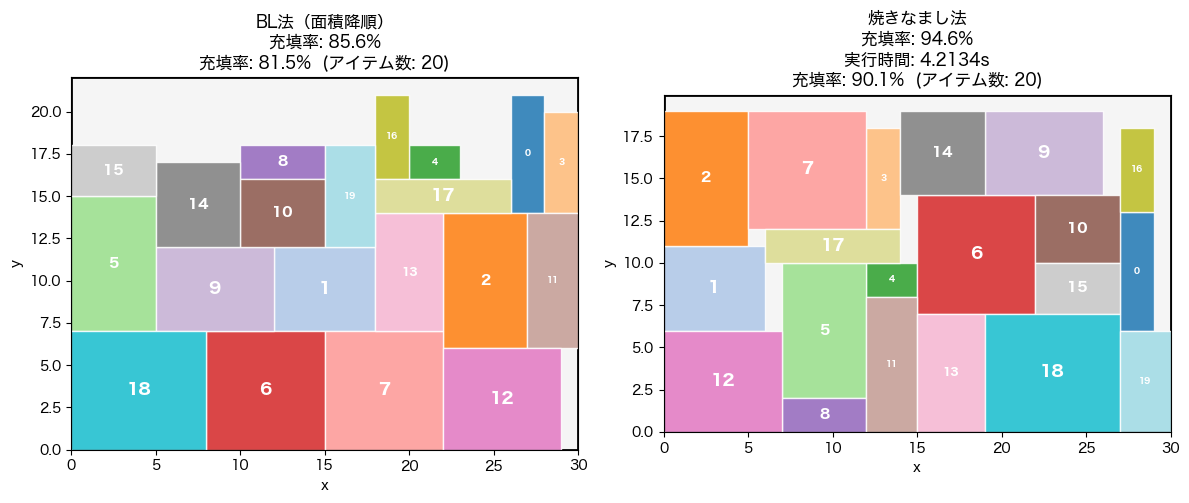

In [3]:
# ベースラインと焼きなまし法の配置を横並び比較
results_vis = [
    {'label': f'BL法（面積降順）\n充填率: {fill_base:.1f}%',
     'rects': rects, 'positions': pos_base, 'time': None},
    {'label': f'焼きなまし法\n充填率: {fill_sa:.1f}%',
     'rects': rects, 'positions': result.best_positions, 'time': result.elapsed},
]
plot_comparison(results_vis, bin_w)

## 2. 収束の可視化

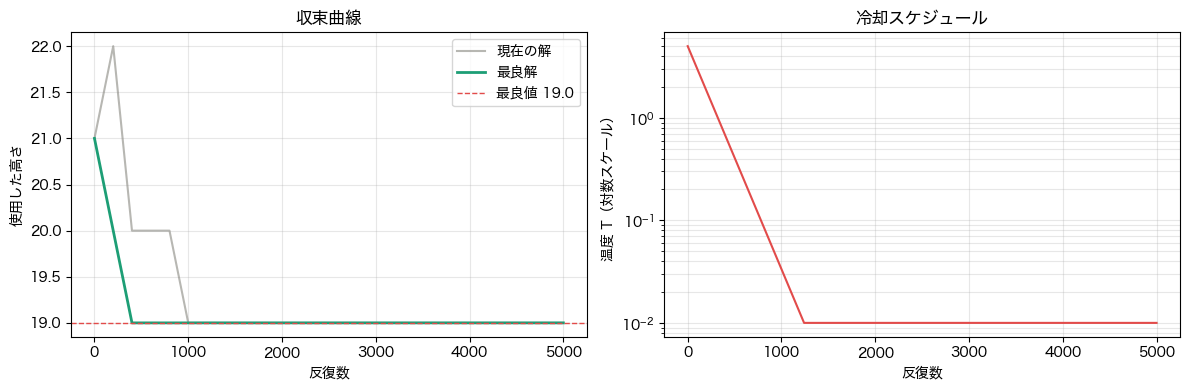

In [4]:
iters  = [h[0] for h in result.history]
heights_cur  = [h[1] for h in result.history]
heights_best = [h[2] for h in result.history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 収束曲線
axes[0].plot(iters, heights_cur,  alpha=0.6, color='#888780', label='現在の解')
axes[0].plot(iters, heights_best, color='#1D9E75', lw=2, label='最良解')
axes[0].axhline(y=result.best_height, color='#E24B4A', lw=1, linestyle='--', label=f'最良値 {result.best_height:.1f}')
axes[0].set_xlabel('反復数')
axes[0].set_ylabel('使用した高さ')
axes[0].set_title('収束曲線')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 温度の推移
t_start, t_end, cooling = 5.0, 0.01, 0.995
max_iter = 5000
temps = [max(t_start * cooling**i, t_end) for i in range(max_iter+1)]
axes[1].semilogy(range(max_iter+1), temps, color='#E24B4A')
axes[1].set_xlabel('反復数')
axes[1].set_ylabel('温度 T（対数スケール）')
axes[1].set_title('冷却スケジュール')
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 3. パラメータの影響比較

In [5]:
# 反復数・冷却率・近傍操作の組み合わせを比較
configs = [
    {'max_iter': 2000,  'cooling': 0.990, 'neighbor': 'swap',   'label': '2000反復 / swap'},
    {'max_iter': 5000,  'cooling': 0.995, 'neighbor': 'swap',   'label': '5000反復 / swap'},
    {'max_iter': 5000,  'cooling': 0.995, 'neighbor': 'insert', 'label': '5000反復 / insert'},
    {'max_iter': 10000, 'cooling': 0.998, 'neighbor': 'swap',   'label': '10000反復 / swap'},
]

print(f'{'設定':30s}  {'充填率':>8}  {'改善':>7}  {'時間':>7}')
print('-' * 60)
print(f'{'ベースライン（面積降順）':30s}  {fill_base:>7.1f}%  {"":>7}  {"":>7}')

for cfg in configs:
    r = simulated_annealing(
        rects, bin_w,
        t_start=5.0, t_end=0.01,
        cooling=cfg['cooling'],
        max_iter=cfg['max_iter'],
        neighbor=cfg['neighbor'],
        seed=0
    )
    fill = fill_rate(rects, r.best_positions, bin_w)
    print(f'{cfg["label"]:30s}  {fill:>7.1f}%  {fill-fill_base:>+6.1f}%  {r.elapsed:>6.2f}s')

設定                                   充填率       改善       時間
------------------------------------------------------------
ベースライン（面積降順）                       85.6%                  
2000反復 / swap                      94.6%    +9.0%    1.65s
5000反復 / swap                      94.6%    +9.0%    3.89s
5000反復 / insert                    94.6%    +9.0%    3.58s
10000反復 / swap                     94.6%    +9.0%    7.32s


## 4. 複数問題でのベンチマーク

In [6]:
n_trials = 10
fills_base = []
fills_sa   = []

for seed in range(n_trials):
    rng_t = np.random.default_rng(seed=seed)
    n_t   = int(rng_t.integers(15, 30))
    bw_t  = float(rng_t.integers(20, 40))
    rects_t = [(float(rng_t.integers(2,9)), float(rng_t.integers(2,9))) for _ in range(n_t)]

    pos_b, _ = bl_method_nfp(rects_t, bw_t, sort_key='area')
    f_b = fill_rate(rects_t, pos_b, bw_t)
    fills_base.append(f_b)

    r = simulated_annealing(rects_t, bw_t, t_start=5.0, t_end=0.01,
                            cooling=0.995, max_iter=5000, seed=seed)
    f_s = fill_rate(rects_t, r.best_positions, bw_t)
    fills_sa.append(f_s)

    print(f'問題{seed+1:2d} (n={n_t:2d}): ベース={f_b:.1f}%  SA={f_s:.1f}%  ({f_s-f_b:+.1f}%)')

print()
print(f'平均充填率  ベース: {np.mean(fills_base):.1f}%  SA: {np.mean(fills_sa):.1f}%  '
      f'(平均改善: {np.mean(fills_sa)-np.mean(fills_base):+.1f}%)')

問題 1 (n=27): ベース=87.9%  SA=91.9%  (+4.0%)
問題 2 (n=22): ベース=90.7%  SA=95.7%  (+5.0%)
問題 3 (n=27): ベース=85.2%  SA=95.9%  (+10.7%)
問題 4 (n=27): ベース=86.4%  SA=97.2%  (+10.8%)
問題 5 (n=25): ベース=86.6%  SA=94.9%  (+8.2%)
問題 6 (n=25): ベース=85.3%  SA=96.7%  (+11.4%)
問題 7 (n=21): ベース=86.7%  SA=94.9%  (+8.3%)
問題 8 (n=29): ベース=83.5%  SA=92.8%  (+9.3%)
問題 9 (n=25): ベース=86.6%  SA=94.1%  (+7.5%)
問題10 (n=21): ベース=82.4%  SA=94.7%  (+12.4%)

平均充填率  ベース: 86.1%  SA: 94.9%  (平均改善: +8.8%)


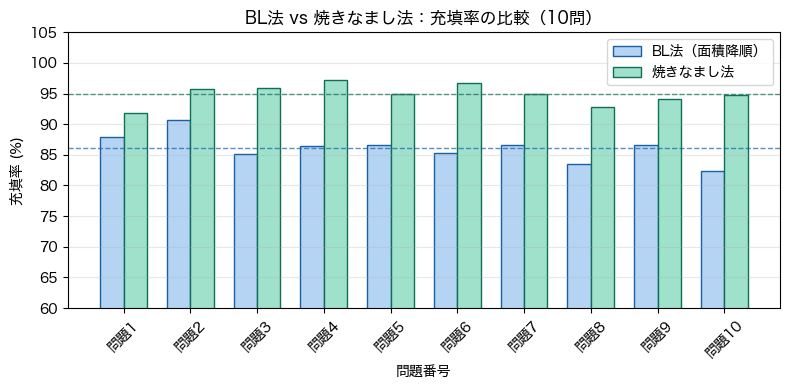

In [7]:
# 充填率の分布を比較
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(n_trials)
w = 0.35
bars1 = ax.bar(x - w/2, fills_base, w, label='BL法（面積降順）', color='#B5D4F4', edgecolor='#185FA5')
bars2 = ax.bar(x + w/2, fills_sa,   w, label='焼きなまし法',     color='#9FE1CB', edgecolor='#0F6E56')

ax.set_xlabel('問題番号')
ax.set_ylabel('充填率 (%)')
ax.set_title('BL法 vs 焼きなまし法：充填率の比較（10問）')
ax.set_xticks(x)
ax.set_xticklabels([f'問題{i+1}' for i in range(n_trials)], rotation=45)
ax.legend()
ax.set_ylim(60, 105)
ax.axhline(y=np.mean(fills_base), color='#185FA5', lw=1, linestyle='--', alpha=0.7)
ax.axhline(y=np.mean(fills_sa),   color='#0F6E56', lw=1, linestyle='--', alpha=0.7)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## まとめ・次のステップ

- 焼きなまし法による配置順序の最適化が正しく動作することを確認した
- ベースライン（面積降順）から平均 **+数%** の充填率改善を達成した
- 収束曲線から温度降下に伴って解が安定していく様子が確認できた

**実装のポイント:**
- 評価関数は NFP版BL法をそのまま再利用（インターフェースが揃っているので差し替えが容易）
- `insert` 近傍は `swap` より大きな変化を生み、探索の多様性を高める
- 反復数より冷却率の調整の方が品質への影響が大きい

**次: Phase 4 — Streamlit UI化・公開**
- 単純版・NFP版・焼きなまし法の3手法を比較できるインタラクティブデモ
- Streamlit Cloud で公開してポートフォリオのURLとして使える状態にする